# Figure 1: Visualizations at the precursor level

## Library imports

If you are using this Jupyter notebook in **Binder** (the lightest version with the already saved data required for plot reproduction), we recommend commenting out and running the cell below to install all the necessary Python packages needed to make this notebook work. 

In [1]:
## Install all necessary Python packages directly in the notebook
!pip install numpy pandas plotly alphatims holoviews psutil datashader pyarrow

  Using cached h5py-3.11.0-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.5 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.0/806.0 kB 19.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached colorcet-3.1.0-py3-none-any.whl.metadata (6.3 kB)
  Preparing metadata (setup.py) ... done
  Using cached pyct-0.6.0-py3-none-any.whl.metadata (7.2 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached multipledispatch-1.0.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached contourpy-1.1.1-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.9 kB)
  Using cached locket-1.0.0-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 95.

If you want to read the raw data on your local PC in the Jupyter notebook, we recommend commenting out and running the cell below to install additional packages to read Thermo data.

Here are instructions on how to install the pythonnet package on different operating systems:
> #### Installing pythonnet on Windows
    > it can be done just installing the pythonnet with pip: pip install pythonnet

> #### Installing pythonnet on Ubuntu (Linux)
    > 1. sudo apt-get install build-essential
    > 2. Intall mono from mono project website [install mono on Linux](https://www.mono-project.com/download/stable/#download-lin)
    > 3. pip install pythonnet

> #### Installing pythonnet on MacOS
> 1. brew install pkg-config
> 2. Intall mono from mono project website;
> 3. "export PKG_CONFIG_PATH=/usr/local/lib/pkgconfig:/usr/lib/pkgconfig:/Library/Frameworks/Mono.framework/Versions/6.12.0/lib/pkgconfig:$PKG_CONFIG_PATH"; `or` add these PKG_CONFIG_PATH into ~./bash_profile, and run "source ~/bash_profile". 6.12.0 is my mono version
> 4. pip install pythonnet

In [2]:
# #only on Windows
!pip install numba tqdm pythonnet

In [2]:
import pandas as pd
import numpy as np

import ext.utils as utils
import ext.fig1_functions as fig1

## Fig 1A: TIC and BPI

**For this figure we used the file `20190124_QX3_JuSc_SA_JS7_1_wt_4h_1.raw` from the [PXD012867 PRIDE project](https://www.ebi.ac.uk/pride/archive/projects/PXD012867).**

* To simplify this step and reproduce it on Binder, load a dataframe `thermo_chrom_ms1` where the information about MS1 scans and the corresponding summed and maximum intensities are already saved across the retention time in a parquet file for you.

In [2]:
thermo_chrom_ms1 = pd.read_parquet('Data/20190124_QX3_JuSc_SA_JS7_1_wt_4h_1_chrom', engine='pyarrow')
thermo_chrom_ms1.head()

,scan,RT,order,summed_intensity,max_intensity
0,1,0.002040,ms1,739489458,57035932
1,17,0.015798,ms1,2000855366,124119728
2,33,0.028040,ms1,1815002750,101905192
3,49,0.040419,ms1,2054335850,100841456
4,65,0.053017,ms1,1774525781,104155856


**To work with the entire file in the Jupyter notebook on your PC, please download the specified file from the PRIDE repository and change the path to it on your PC. To do this, comment out and run the code below.**

* **Troubleshooting**: In case you get the error "ModuleNotFoundError: No module named 'pyrawfilereader'" while running this cell, please refer to the documentation at the beginning of the notebook about reading Thermo raw data on PC.

In [5]:
# # specify a path to the Thermo .raw file
# sample_path = '.../Data/PXD012867_yeast_project/20190124_QX3_JuSc_SA_JS7_1_wt_4h_1.raw'

# # upload the thermo raw file
# data = utils.load_thermo_raw(sample_path)

# # save ms1 separately 
# df_ms1 = pd.DataFrame({'scan': data['scan_list_ms1'], 
#                     'RT': data['rt_list_ms1'],
#                    'intensity': data['int_list_ms1'],
#                     'order': 'ms1'})

# # calculate summed and max intensity per each scan
# df_ms1['summed_intensity'] = df_ms1.intensity.apply(lambda x: sum(x))
# df_ms1['max_intensity'] = df_ms1.intensity.apply(lambda x: max(x))
# df_ms1.head()

**To assess the performance of the LC and the MS instruments, one can inspect how many precursor ions reach the MS detector over time, visualized in the total ion chromatogram (TIC) or base peak intensity (BPI) plot. They show the summed intensity of all detected precursor ions (TIC) or the intensity of the most abundant ions (BPI) against the retention time.**

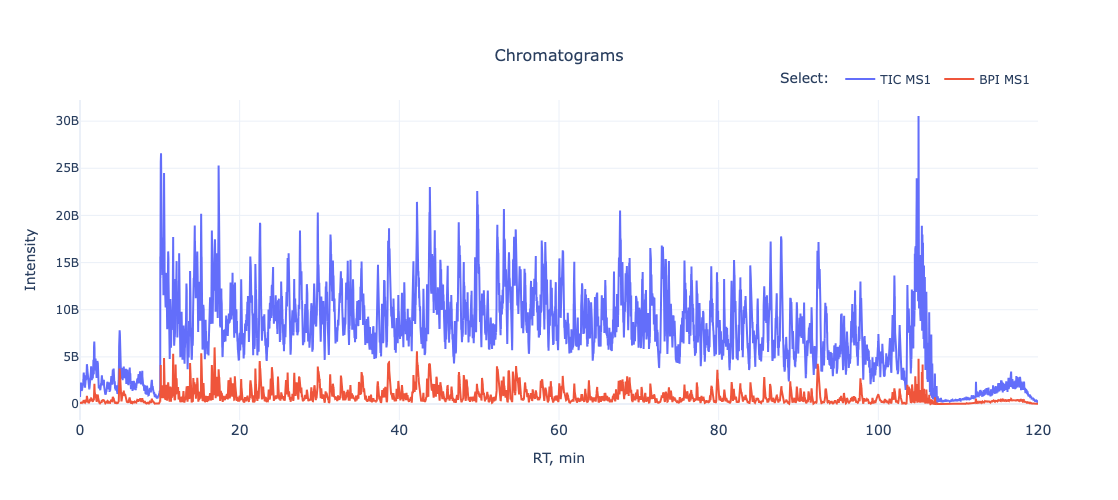

In [3]:
fig1.plot_tic(thermo_chrom_ms1, 'Chromatograms').show(config=utils.config)

**These two plots can reveal a lot of issues, such as poor peak separation (very broad peaks), unstable spray or MS failure (intensity drops), mistakes in sample preparation (low intensity, few peaks, unexpected overall shape), overloading or contamination.**

## Fig 1B: XIC

**For this figure we used the same file as for the Fig 1A (`20190124_QX3_JuSc_SA_JS7_1_wt_4h_1.raw` file from [PXD012867 PRIDE project](https://www.ebi.ac.uk/pride/archive/projects/PXD012867)).**

* To simplify this step and reproduce it on Binder, load a dataframe `thermo_ms1` where MS1 precursor information (m/z and intensity) is already stored in a parquet file for you.

In [5]:
thermo_ms1 = pd.read_parquet(
    ['Data/20190124_QX3_JuSc_SA_JS7_1_wt_4h_1_ms1_part1',
     'Data/20190124_QX3_JuSc_SA_JS7_1_wt_4h_1_ms1_part2'], 
    engine='pyarrow'
)
thermo_ms1.head()

,RT,mz,intensity
0,0.00204,300.143433,60268
1,0.00204,300.160583,64932
2,0.00204,300.179596,51113
3,0.00204,300.476562,13740
4,0.00204,300.595093,24882


**To work with the entire file in the Jupyter notebook on your PC, please refer to the instructions for Fig. 1A.**

**To follow up on individual detected ions or groups of ions, extracted ion chromatograms (XICs) can be used. The desired mass and charge range (`m/z = 457.997855`) is extracted from the raw data and its intensity is plotted against the retention time. In doing so it is important to set adequate boundaries to the mass range (`m/z tolerance = 5 ppm`), accounting for mass errors and coeluting ions.**

In [6]:
fig1.plot_xic(
    df=thermo_ms1, 
    xic_mz=457.997855, 
    mz_tol_value=5, 
    rt_min=0, 
    rt_max=thermo_ms1.RT.max(), 
    bins=300
).show(config=utils.config)

**This plot can assist in evaluating e.g. the spread of contaminants, the peak shape of quality control ions or the quality of identified peptide features.**

## Fig 1C: MS1 map

**For this figure we used the same file as for the Fig 1A (`20190124_QX3_JuSc_SA_JS7_1_wt_4h_1.raw` file from [PXD012867 PRIDE project](https://www.ebi.ac.uk/pride/archive/projects/PXD012867)).**

* To simplify this step and reproduce it on Binder, load a dataframe `thermo_ms1` where MS1 precursor information (m/z and intensity) is already stored in a parquet file for you.

In [6]:
thermo_ms1 = pd.read_parquet(
    ['Data/20190124_QX3_JuSc_SA_JS7_1_wt_4h_1_ms1_part1',
     'Data/20190124_QX3_JuSc_SA_JS7_1_wt_4h_1_ms1_part2'], 
    engine='pyarrow'
)
thermo_ms1.head()

,RT,mz,intensity
0,0.00204,300.143433,60268
1,0.00204,300.160583,64932
2,0.00204,300.179596,51113
3,0.00204,300.476562,13740
4,0.00204,300.595093,24882


**To work with the entire file in the Jupyter notebook on your PC, please refer to the instructions for Fig. 1A.**

**To get an overview of the whole range of precursor masses detected along the retention time, a 2D MS1 map can be used. It shows the intensity (color) of observed precursor masses (x-axis) across the chromatographic retention time (y-axis) as a heatmap.**

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
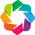

ValueError: Callable parameter 'Callable.callable' only takes a callable object, not objects of <class 'holoviews.element.geom.Points'>.

In [7]:
fig1.plot_heatmap_ms1(thermo_ms1, title='MS1 map')

**Similar to the TIC plot, it allows to detect technical issues with the instrument.**

## Fig 1D: MS1 ion mobility heatmap

**For this figure we used the raw Bruker file from [Project PXD017703 from ProteomeXchange](https://www.ebi.ac.uk/pride/archive/projects/PXD017703) as example data.**

* To read the raw TIMS-TOF data we used the recently published package [AlphaTims](https://github.com/MannLabs/alphatims).

**! IMPORTANT. To obtain the same plots as shown in the review please read the Bruker data with AlphaTims on Windows or Linux OS.**

* To simplify this step and reproduce it on Binder, load the dataframe `bruker_df` where one MS1 frame (#6004) in the middle of the gradient has already been saved in a parquet file for you. 

In [11]:
bruker_df = pd.read_parquet(
    'Data/20200428_Evosep_60SPD_SG06-16_MLHeLa_200ng_py8_S3-A6_1_2452_frame', 
    engine='pyarrow'
)
bruker_df.head()

,raw_indices,frame_indices,scan_indices,precursor_indices,push_indices,tof_indices,rt_values,rt_values_min,mobility_values,quad_low_mz_values,quad_high_mz_values,mz_values,intensity_values
0,279083635,6004,33,0,5517709,211464,633.716165,10.561936,1.601114,-1.0,-1.0,694.773080,9
1,279083636,6004,35,0,5517711,326378,633.716165,10.561936,1.598886,-1.0,-1.0,1252.148662,9
2,279083637,6004,36,0,5517712,35698,633.716165,10.561936,1.597771,-1.0,-1.0,157.530243,9
3,279083638,6004,36,0,5517712,50307,633.716165,10.561936,1.597771,-1.0,-1.0,187.655130,9
4,279083639,6004,36,0,5517712,64580,633.716165,10.561936,1.597771,-1.0,-1.0,219.631055,9


**To work with the entire file in the Jupyter notebook on your PC, please download the specified file from the PRIDE repository and change the path to it on your PC. To do this, comment out and run the code below.**

In [12]:
# file_path = '../Data/PXD017703_diaPASEF/20200428_Evosep_60SPD_SG06-16_MLHeLa_200ng_py8_S3-A6_1_2452.d'

# raw_data = alphatims.bruker.TimsTOF(file_path)
# raw_data[6004].head()

**Using the advantage of the additional dimension in the Bruker data, precursor signal intensities can be visualized in the ion mobility dimension against the m/z dimension similar to the MS1 map. But this heatmap is even more informative because it shows the intensity across all three dimensions (retention time, ion mobility and m/z).**

:DynamicMap   []
   :RGB   [mz_values,mobility_values]   (R,G,B,A)
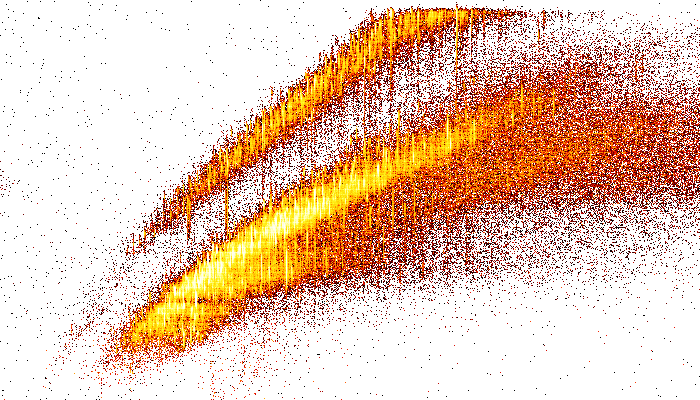

In [13]:
# this heatmap is generated for the MS1 frame № 6004 in the middle of the gradient
fig1.plot_heatmap(bruker_df, title='MS1 ion mobility heatmap')